In [ ]:
%pip install "git+https://github.com/Mishne-Lab/pyRATS[examples]"

In [ ]:
from matplotlib import pyplot as plt

from pyRATS import rats
import datasets, vis

import time

matplotlib.get_backend() =  module://matplotlib_inline.backend_inline


# Load data

In [2]:
X, labels, ddX = datasets.Datasets().barbell()

X.shape =  (10227, 2)


# Generate embeddings

In [ ]:
model = rats.RATS(
    n_components=2,
    n_neighbors=28,
    min_cluster_size=5,
    tear=True,
)

start = time.time()

y = model.fit_transform(X=X)

end = time.time()
y, f'runtime: {end - start}'

(array([[ 1.47287528, -0.12034955],
        [ 1.4731505 , -0.11041265],
        [ 1.47342571, -0.10047574],
        ...,
        [-0.74667959,  0.05051391],
        [-0.74640438,  0.06045082],
        [-0.74612916,  0.07038773]], shape=(10227, 2)),
 'runtime: 57.347469091415405')

# Tear coloring

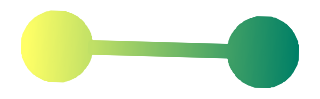

In [4]:
tear_color_eig_inds = [0,1,2] # interior has green color so assigned smallest value of i to g-channel
color_of_pts_on_tear = model.compute_color_of_pts_on_tear(
    y,
    tear_color_eig_inds
)
vis.Visualize().global_embedding(
    y, labels[:,0],
    color_of_pts_on_tear=color_of_pts_on_tear[:,tear_color_eig_inds] if color_of_pts_on_tear is not None else None,
    cmap0='summer', cmap1='jet',
    title='color='+str(tear_color_eig_inds),
    figsize=(3, 3)
)
plt.show()